# 📚 BEGINNER'S BOOK: Understanding Linear Regression
## A Simple, Visual Guide to Slope, Intercept, and Coefficients

### What You'll Learn:
✅ What is a **slope**? (and why it matters)
✅ What is an **intercept**? (and where it comes from)
✅ What are **coefficients**? (they're just fancy names for numbers!)
✅ How to predict things using a simple line
✅ REAL examples with actual data

**No scary math. Just understanding.**

## 1️⃣ REAL WORLD STORY: Coffee Shop Sales 

Let's start with something you know - a coffee shop!

**The Question:** If we know how many customers came in, can we predict how much money we'll make?

| Customers | Sales ($) |
|-----------|-----------|
| 10        | 200       |
| 20        | 400       |
| 30        | 600       |
| 40        | 800       |

**What do you notice?** 
- When customers = 10 → Sales = 200
- When customers = 40 → Sales = 800

**The pattern:** Every 10 more customers = $200 more in sales!

This pattern is what we call the **SLOPE** 💰

## 2️⃣ THE MAGIC FORMULA

Here's the formula that POWERS linear regression:

### $ y = mx + b $

**Breaking it down:**
- **y** = What we want to predict (Sales)
- **x** = What we know (Customers)  
- **m** = SLOPE (how much y changes for each x)
- **b** = INTERCEPT (starting point)

### BUT WAIT... we have DIFFERENT NAMES for these!

In statistics, scientists like to use Greek letters (to look smart 😎):

| Name | Symbol | Means | Example |
|------|--------|-------|---------|
| **Intercept** | β₀ (beta-zero) | Starting point, "b" | $50 (base revenue) |
| **Slope** | β₁ (beta-one) | Change rate, "m" | $20 per customer |
| **Coefficient** | β | Any number (β₀ or β₁) | Could be either |

**🔑 KEY:** Coefficient just means "a number in our equation"!

So our equation becomes: **$ Price = β₀ + β₁ × Customers $**

It's the SAME formula, just with fancier names!

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression

# Let's create the coffee shop data
customers = np.array([10, 20, 30, 40])
sales = np.array([200, 400, 600, 800])

print("=" * 60)
print("COFFEE SHOP DATA")
print("=" * 60)
print(f"Customers: {customers}")
print(f"Sales ($): {sales}")
print()

# Reshape for sklearn (it needs 2D array)
X = customers.reshape(-1, 1)  # Independent variable (what we know)
y = sales                       # Dependent variable (what we predict)

# Create and fit the model
model = LinearRegression()
model.fit(X, y)

# Extract the coefficients
intercept = model.intercept_  # This is β₀ (b)
slope = model.coef_[0]        # This is β₁ (m)

print(f"INTERCEPT (β₀) = {intercept}")
print(f"SLOPE (β₁) = {slope}")
print()
print(f"Our equation: Sales = {intercept} + {slope} × Customers")
print("=" * 60)

COFFEE SHOP DATA
Customers: [10 20 30 40]
Sales ($): [200 400 600 800]

INTERCEPT (β₀) = 0.0
SLOPE (β₁) = 20.0

Our equation: Sales = 0.0 + 20.0 × Customers
INTERCEPT (β₀) = 0.0
SLOPE (β₁) = 20.0

Our equation: Sales = 0.0 + 20.0 × Customers


## 3️⃣ WHAT DID WE JUST LEARN?

From the coffee shop data:
- **INTERCEPT (β₀) = 0**: This means if NO customers come, we make $0 (makes sense for a coffee shop!)
- **SLOPE (β₁) = 20**: This means for EVERY 1 additional customer, we make $20 more

So if 25 customers come:
**Sales = 0 + 20 × 25 = $500**

---

## 4️⃣ LET'S VISUALIZE IT (Show the line!)

When we plot this, we see a straight line!

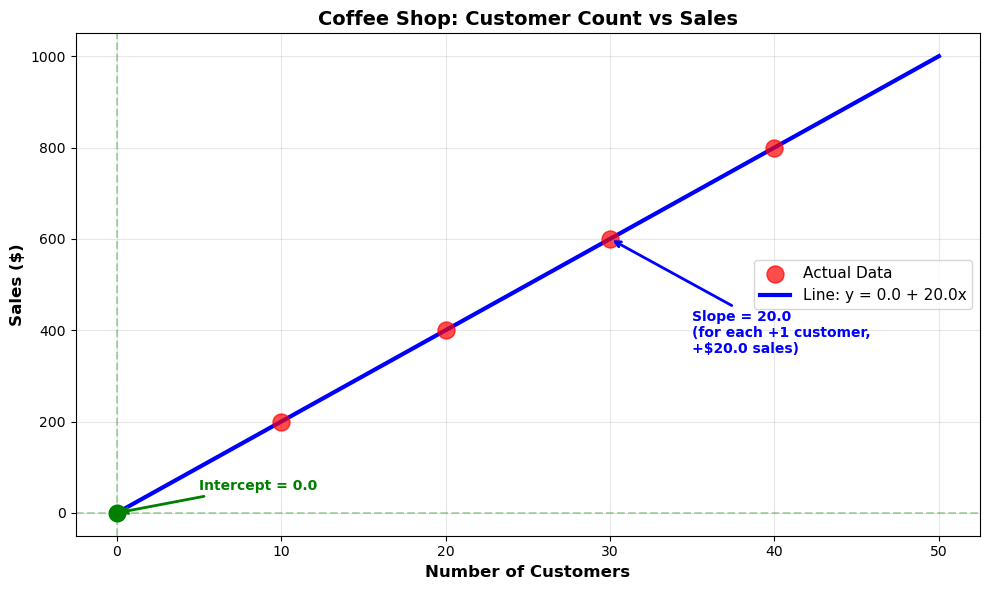


✨ WHAT THE VISUALIZATION SHOWS:
   • BLUE LINE: Our prediction line (using slope and intercept)
   • RED DOTS: The actual data we observed
   • GREEN POINT: The INTERCEPT (where line touches y-axis)
   • The SLOPE controls how STEEP the line is


In [24]:
# Create a beautiful visualization
fig, ax = plt.subplots(figsize=(10, 6))

# Plot actual data points (red dots)
ax.scatter(customers, sales, s=150, color='red', label='Actual Data', zorder=3, alpha=0.7)

# Create the line (predictions)
x_line = np.linspace(0, 50, 100)
y_line = intercept + slope * x_line
ax.plot(x_line, y_line, 'b-', linewidth=3, label=f'Line: y = {intercept} + {slope}x')

# Add labels and title
ax.set_xlabel('Number of Customers', fontsize=12, fontweight='bold')
ax.set_ylabel('Sales ($)', fontsize=12, fontweight='bold')
ax.set_title('Coffee Shop: Customer Count vs Sales', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

# Highlight the intercept (where the line crosses y-axis)
ax.plot(0, intercept, 'go', markersize=12, label=f'INTERCEPT (β₀) = {intercept}', zorder=4)
ax.axvline(x=0, color='green', linestyle='--', alpha=0.3)
ax.axhline(y=intercept, color='green', linestyle='--', alpha=0.3)

# Add annotation for intercept
ax.annotate(f'Intercept = {intercept}', xy=(0, intercept), xytext=(5, intercept+50),
            fontsize=10, color='green', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='green', lw=2))

# Add annotation for slope
ax.annotate(f'Slope = {slope}\n(for each +1 customer,\n+${slope} sales)', 
            xy=(30, 600), xytext=(35, 350),
            fontsize=10, color='blue', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='blue', lw=2))

plt.tight_layout()
plt.show()

print("\n✨ WHAT THE VISUALIZATION SHOWS:")
print(f"   • BLUE LINE: Our prediction line (using slope and intercept)")
print(f"   • RED DOTS: The actual data we observed")
print(f"   • GREEN POINT: The INTERCEPT (where line touches y-axis)")
print(f"   • The SLOPE controls how STEEP the line is")

## 5️⃣ UNDERSTANDING THE INTERCEPT BETTER

### What is the INTERCEPT (β₀)?

**Simple Answer:** It's the value on the y-axis where the line starts (when x = 0)

**Real World Example:**
```
Coffee Shop Revenue = 0 + 20 × Customers

If 0 customers come → Revenue = 0 + 20 × 0 = $0
If 10 customers come → Revenue = 0 + 20 × 10 = $200
If 50 customers come → Revenue = 0 + 20 × 50 = $1,000
```

In our coffee shop case, intercept = 0 because if NO ONE comes, we make NO money.

### But what if the intercept was NOT zero?

Imagine a restaurant with a $100/day overhead cost:
```
Restaurant Revenue = 100 + 30 × Customers

If 0 customers → Revenue = 100 + 30 × 0 = $100 (we lose $100!)
If 10 customers → Revenue = 100 + 30 × 10 = $400 (we make $400)
```

**🔑 KEY INSIGHT:** The intercept can be:
- **Positive:** Extra money you start with
- **Zero:** You start with nothing
- **Negative:** You start with a loss (like debt or overhead)

## 6️⃣ UNDERSTANDING THE SLOPE BETTER

### What is the SLOPE (β₁)?

**Simple Answer:** How much does y change for every 1 unit change in x?

**Think of it like a hill:**
- **Steep slope (large number):** The hill goes UP really fast
- **Gentle slope (small number):** The hill is almost flat
- **Zero slope:** The line is completely flat (no change)
- **Negative slope:** The line goes DOWN (inverse relationship)

### Examples with DIFFERENT slopes:

| Scenario | Equation | Meaning |
|----------|----------|---------|
| Coffee shop | Sales = 0 + **20** × Customers | For each customer: +$20 |
| Gas usage | Gallons = 5 + **0.05** × Miles | For each mile: +0.05 gallons |
| Depression | Happiness = 100 + **-5** × Stress | For each stressful thing: -5 happiness |
| Learning | Score = 40 + **3** × Hours Studied | For each hour: +3 points |

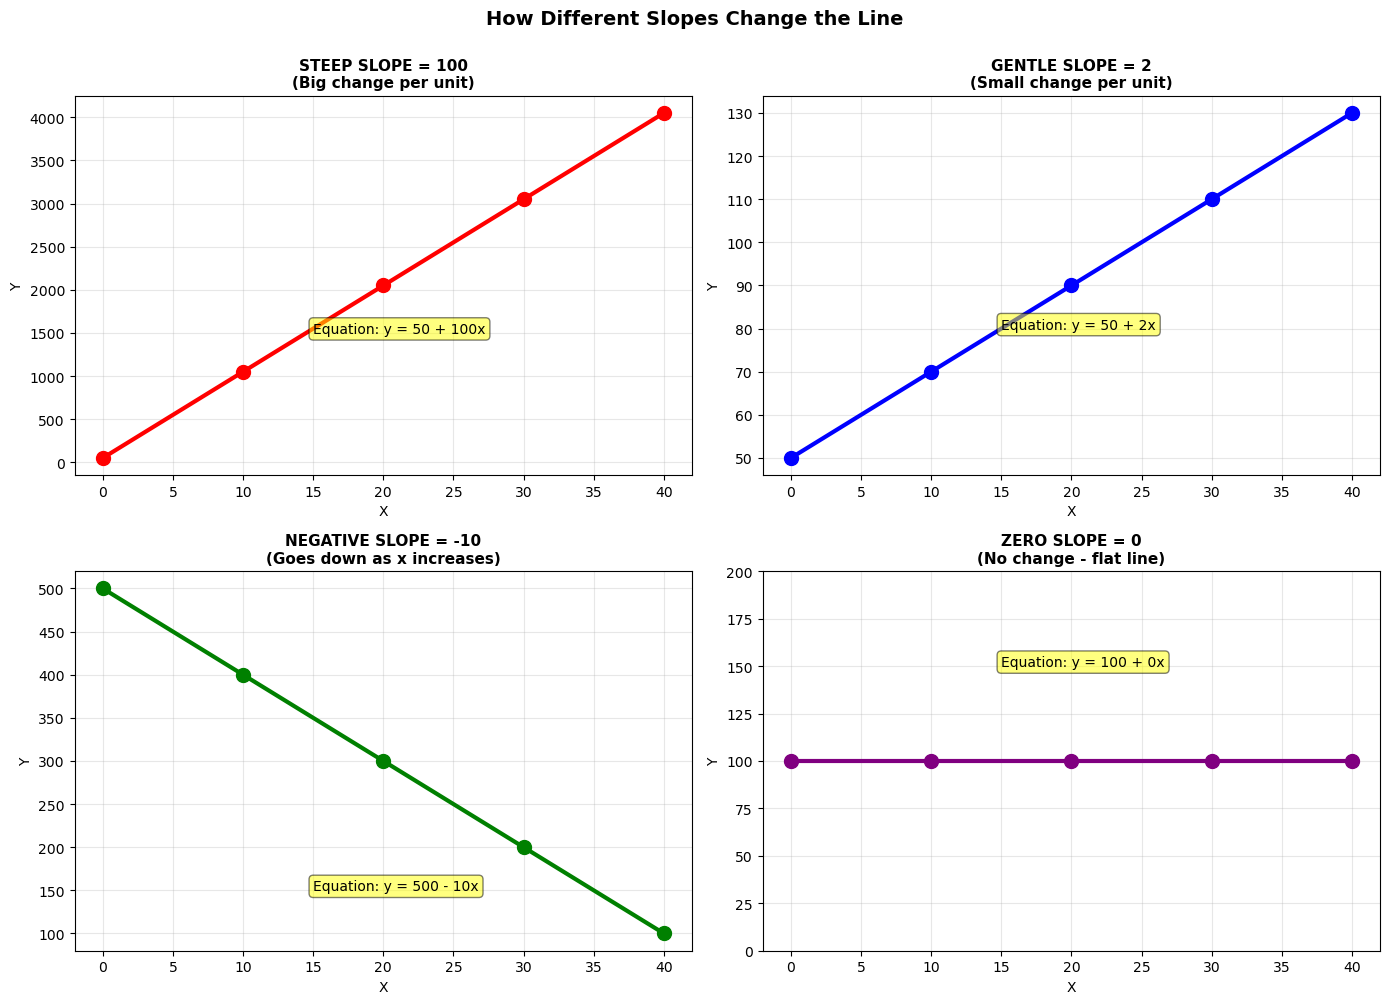

KEY TAKEAWAY:
• STEEP slope (100): Line goes UP fast
• GENTLE slope (2): Line goes UP slowly
• NEGATIVE slope (-10): Line goes DOWN
• ZERO slope (0): Line is FLAT (horizontal)

The slope determines HOW MUCH y changes when x changes!


In [25]:
# Let's visualize DIFFERENT slopes side by side!

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Scenario 1: STEEP positive slope (fast change)
ax = axes[0, 0]
x1 = np.array([0, 10, 20, 30, 40])
y1 = 50 + 100 * x1  # Steep slope = 100
ax.scatter(x1, y1, s=100, color='red', zorder=3)
ax.plot(x1, y1, 'r-', linewidth=3)
ax.set_title('STEEP SLOPE = 100\n(Big change per unit)', fontweight='bold', fontsize=11)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.grid(True, alpha=0.3)
ax.text(15, 1500, 'Equation: y = 50 + 100x', fontsize=10, 
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

# Scenario 2: Gentle positive slope (slow change)
ax = axes[0, 1]
x2 = np.array([0, 10, 20, 30, 40])
y2 = 50 + 2 * x2  # Gentle slope = 2
ax.scatter(x2, y2, s=100, color='blue', zorder=3)
ax.plot(x2, y2, 'b-', linewidth=3)
ax.set_title('GENTLE SLOPE = 2\n(Small change per unit)', fontweight='bold', fontsize=11)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.grid(True, alpha=0.3)
ax.text(15, 80, 'Equation: y = 50 + 2x', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

# Scenario 3: Negative slope (downward trend)
ax = axes[1, 0]
x3 = np.array([0, 10, 20, 30, 40])
y3 = 500 + (-10) * x3  # Negative slope = -10
ax.scatter(x3, y3, s=100, color='green', zorder=3)
ax.plot(x3, y3, 'g-', linewidth=3)
ax.set_title('NEGATIVE SLOPE = -10\n(Goes down as x increases)', fontweight='bold', fontsize=11)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.grid(True, alpha=0.3)
ax.text(15, 150, 'Equation: y = 500 - 10x', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

# Scenario 4: Zero slope (flat line)
ax = axes[1, 1]
x4 = np.array([0, 10, 20, 30, 40])
y4 = 100 + 0 * x4  # Zero slope = 0
ax.scatter(x4, y4, s=100, color='purple', zorder=3)
ax.plot(x4, y4, 'purple', linewidth=3)
ax.set_title('ZERO SLOPE = 0\n(No change - flat line)', fontweight='bold', fontsize=11)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 200)
ax.text(15, 150, 'Equation: y = 100 + 0x', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

plt.suptitle('How Different Slopes Change the Line', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("KEY TAKEAWAY:")
print("=============")
print("• STEEP slope (100): Line goes UP fast")
print("• GENTLE slope (2): Line goes UP slowly")
print("• NEGATIVE slope (-10): Line goes DOWN")
print("• ZERO slope (0): Line is FLAT (horizontal)")
print("\nThe slope determines HOW MUCH y changes when x changes!")

## 7️⃣ REAL WORLD EXAMPLE: Manhattan vs New Jersey House Prices

### Remember those numbers from the beginning?
- **756.9** - The SLOPE (β₁)
- **-27153.8** - The INTERCEPT (β₀)

This was for: **House Price = -27153.8 + 756.9 × Square Feet**

**Wait... negative intercept? That seems weird!**

**Here's why it makes sense:**
- This is just the mathematical line that BEST FITS the data
- The negative intercept doesn't mean "negative price" - it's just math!
- For real predictions, we use actual square footage (positive numbers)
- So the negative part gets "balanced out"

### Let's see a REAL example:

**Manhattan House: 2000 sq ft**
```
Price = -27153.8 + 756.9 × 2000
Price = -27153.8 + 1,513,800
Price = $1,486,646 ✅ (Makes sense!)
```

**New Jersey House: 2000 sq ft**
Same house size, but in a different neighborhood might cost less...
```
Maybe: Price = 50000 + 150 × 2000
Price = 50000 + 300,000
Price = $350,000 ✅ (Cheaper, makes sense!)
```

**The key insight:** Different locations have DIFFERENT slopes and intercepts!
- Manhattan: High slope (expensive per sq ft), negative intercept (adjusted for market)
- New Jersey: Lower slope (cheaper per sq ft), positive intercept (base price)

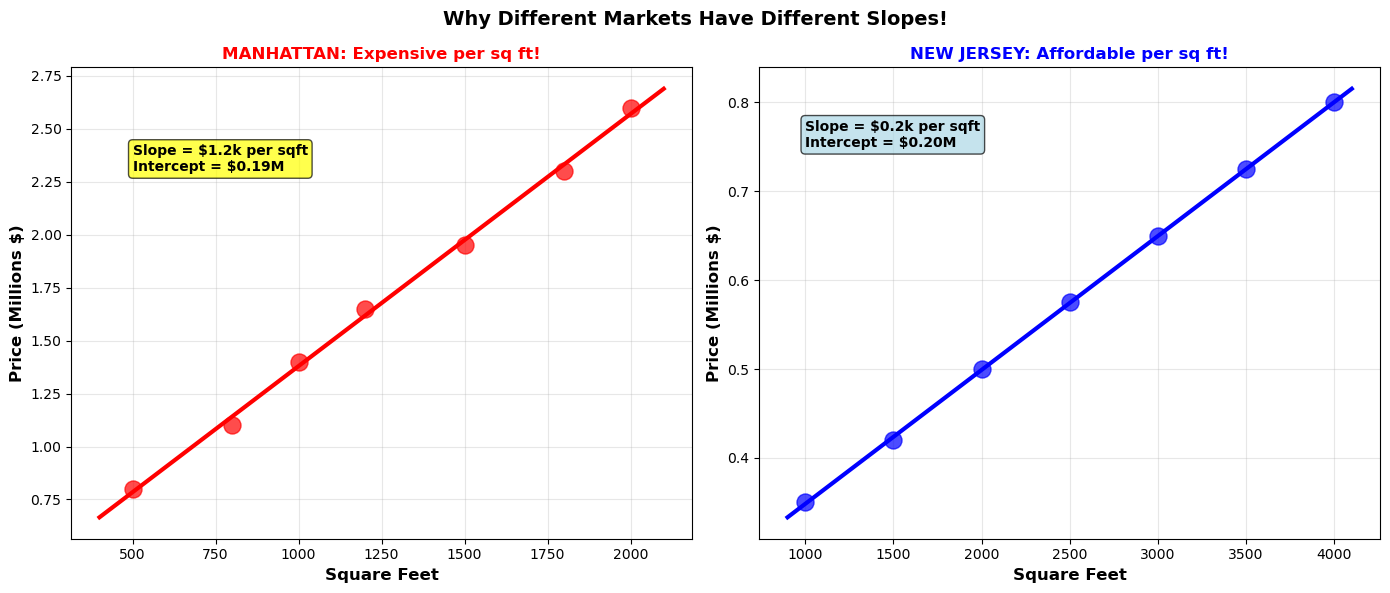

🏘️  COMPARISON:
MANHATTAN:
  • Slope: $1.2k per sq ft (EXPENSIVE!)
  • A 2000 sqft house: $2.57M

NEW JERSEY:
  • Slope: $0.2k per sq ft (Cheaper)
  • A 2000 sqft house: $0.50M

SAME SIZE, DIFFERENT PRICE because they have different SLOPES!


In [26]:
# Let's visualize Manhattan vs New Jersey with real-looking data

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# MANHATTAN DATA (expensive!)
manhattan_sqft = np.array([500, 800, 1000, 1200, 1500, 1800, 2000])
manhattan_price = np.array([800000, 1100000, 1400000, 1650000, 1950000, 2300000, 2600000])

ax = axes[0]
ax.scatter(manhattan_sqft, manhattan_price/1e6, s=150, color='red', alpha=0.7, zorder=3)

# Fit line to Manhattan
m_model = LinearRegression()
m_model.fit(manhattan_sqft.reshape(-1, 1), manhattan_price)
m_slope = m_model.coef_[0]
m_intercept = m_model.intercept_

x_line = np.linspace(400, 2100, 100)
y_line = (m_intercept + m_slope * x_line) / 1e6
ax.plot(x_line, y_line, 'r-', linewidth=3)

ax.set_xlabel('Square Feet', fontsize=12, fontweight='bold')
ax.set_ylabel('Price (Millions $)', fontsize=12, fontweight='bold')
ax.set_title('MANHATTAN: Expensive per sq ft!', fontsize=12, fontweight='bold', color='red')
ax.grid(True, alpha=0.3)
ax.text(500, 2.3, f'Slope = ${m_slope/1000:.1f}k per sqft\nIntercept = ${m_intercept/1e6:.2f}M', 
        fontsize=10, bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7), fontweight='bold')

# NEW JERSEY DATA (affordable!)
nj_sqft = np.array([1000, 1500, 2000, 2500, 3000, 3500, 4000])
nj_price = np.array([350000, 420000, 500000, 575000, 650000, 725000, 800000])

ax = axes[1]
ax.scatter(nj_sqft, nj_price/1e6, s=150, color='blue', alpha=0.7, zorder=3)

# Fit line to New Jersey
nj_model = LinearRegression()
nj_model.fit(nj_sqft.reshape(-1, 1), nj_price)
nj_slope = nj_model.coef_[0]
nj_intercept = nj_model.intercept_

x_line_nj = np.linspace(900, 4100, 100)
y_line_nj = (nj_intercept + nj_slope * x_line_nj) / 1e6
ax.plot(x_line_nj, y_line_nj, 'b-', linewidth=3)

ax.set_xlabel('Square Feet', fontsize=12, fontweight='bold')
ax.set_ylabel('Price (Millions $)', fontsize=12, fontweight='bold')
ax.set_title('NEW JERSEY: Affordable per sq ft!', fontsize=12, fontweight='bold', color='blue')
ax.grid(True, alpha=0.3)
ax.text(1000, 0.75, f'Slope = ${nj_slope/1000:.1f}k per sqft\nIntercept = ${nj_intercept/1e6:.2f}M', 
        fontsize=10, bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7), fontweight='bold')

plt.suptitle('Why Different Markets Have Different Slopes!', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("🏘️  COMPARISON:")
print("=" * 70)
print(f"MANHATTAN:")
print(f"  • Slope: ${m_slope/1000:.1f}k per sq ft (EXPENSIVE!)")
print(f"  • A 2000 sqft house: ${(m_intercept + m_slope * 2000)/1e6:.2f}M")
print()
print(f"NEW JERSEY:")
print(f"  • Slope: ${nj_slope/1000:.1f}k per sq ft (Cheaper)")
print(f"  • A 2000 sqft house: ${(nj_intercept + nj_slope * 2000)/1e6:.2f}M")
print()
print(f"SAME SIZE, DIFFERENT PRICE because they have different SLOPES!")
print("=" * 70)

## 8️⃣ HOW DOES MACHINE LEARNING FIND THE SLOPE & INTERCEPT?

**The Big Question:** How does the computer know what numbers to use for slope and intercept?

**Answer:** It TRIES MANY combinations until it finds the one that makes the least errors!

### Simple Explanation:

1. **Start with random guesses** for slope and intercept
2. **Make predictions** using those guesses
3. **Calculate errors** (how far off are our predictions?)
4. **Improve the guesses** to make errors smaller
5. **Repeat** until we can't improve anymore

It's like throwing darts:
- First few darts: Miss badly
- Keep throwing, adjusting: Getting closer
- Eventually: Hit the bullseye (or very close!)

### What Are We Trying to Minimize?

We count the total error using something called **Mean Squared Error (MSE)**:

$$\text{MSE} = \frac{1}{n}\sum_{i=1}^{n}(y_{actual} - y_{predicted})^2$$

**Breaking it down:**
- $(y_{actual} - y_{predicted})$: Error for each prediction
- We SQUARE each error (makes big errors matter more)
- We take the AVERAGE of all squared errors
- We find slope and intercept that make this number as SMALL as possible

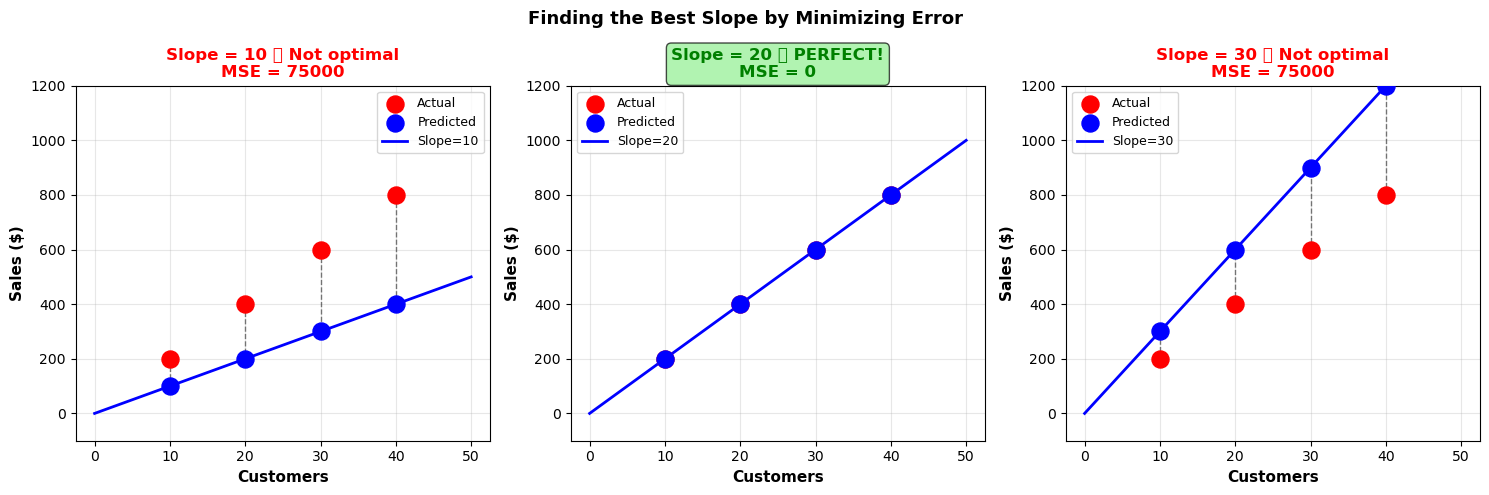

WHAT YOU SEE:
• LEFT: Slope too small (10) → Predictions too low → BIG errors ❌
• MIDDLE: Slope just right (20) → Perfect predictions → NO errors ✅
• RIGHT: Slope too big (30) → Predictions too high → BIG errors ❌

The algorithm finds the slope that minimizes MSE (makes errors smallest!)


In [27]:
# Let's show how DIFFERENT slopes create DIFFERENT errors

# Using our coffee shop data again
customers = np.array([10, 20, 30, 40])
actual_sales = np.array([200, 400, 600, 800])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Try 3 different slopes!
slopes_to_try = [10, 20, 30]  # The correct slope is 20!

for idx, slope in enumerate(slopes_to_try):
    ax = axes[idx]
    
    # Our predictions with this slope (intercept = 0 for simplicity)
    predicted_sales = 0 + slope * customers
    
    # Calculate error
    errors = actual_sales - predicted_sales
    squared_errors = errors ** 2
    mse = np.mean(squared_errors)
    
    # Plot
    ax.scatter(customers, actual_sales, s=150, color='red', label='Actual', zorder=3)
    ax.scatter(customers, predicted_sales, s=150, color='blue', label='Predicted', zorder=3)
    
    # Draw error lines
    for i in range(len(customers)):
        ax.plot([customers[i], customers[i]], [actual_sales[i], predicted_sales[i]], 
                'k--', alpha=0.5, linewidth=1)
    
    # Plot the line
    x_line = np.array([0, 50])
    y_line = 0 + slope * x_line
    ax.plot(x_line, y_line, 'b-', linewidth=2, label=f'Slope={slope}')
    
    ax.set_xlabel('Customers', fontsize=11, fontweight='bold')
    ax.set_ylabel('Sales ($)', fontsize=11, fontweight='bold')
    
    if slope == 20:
        ax.set_title(f'Slope = {slope} ✅ PERFECT!\nMSE = {mse:.0f}', 
                    fontsize=12, fontweight='bold', color='green',
                    bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))
    else:
        ax.set_title(f'Slope = {slope} ❌ Not optimal\nMSE = {mse:.0f}', 
                    fontsize=12, fontweight='bold', color='red')
    
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    ax.set_ylim(-100, 1200)

plt.suptitle('Finding the Best Slope by Minimizing Error', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("WHAT YOU SEE:")
print("=" * 70)
print("• LEFT: Slope too small (10) → Predictions too low → BIG errors ❌")
print("• MIDDLE: Slope just right (20) → Perfect predictions → NO errors ✅")
print("• RIGHT: Slope too big (30) → Predictions too high → BIG errors ❌")
print()
print("The algorithm finds the slope that minimizes MSE (makes errors smallest!)")
print("=" * 70)

## 9️⃣ YOUR VOCABULARY CHEAT SHEET

| Fancy Name | Simple Name | Symbol | What It Means |
|-----------|-------------|--------|--------------|
| **Coefficient** | Just a number | β | Any coefficient (β₀ or β₁) |
| **Intercept** | Starting point, "b" | β₀ | Where the line touches y-axis (when x=0) |
| **Slope** | Rate of change, "m" | β₁ | How much y changes for each x |
| **Linear Regression** | Line fitting | - | Finding the best line through data |
| **Mean Squared Error** | Average squared mistakes | MSE | Sum of error² ÷ number of points |
| **Prediction** | Our guess | ŷ | What we think y will be |
| **Actual** | Real value | y | The true value we observed |
| **Error/Residual** | How wrong we were | ε | actual - predicted |

---

## 🔟 QUICK SUMMARY IN 10 SECONDS

✅ **Slope (β₁):** How steep is the line? (fast change = steep, slow change = gentle)

✅ **Intercept (β₀):** Where does the line start? (y-value when x=0)

✅ **Coefficient:** Just fancy word for "number in the equation"

✅ **Equation:** y = β₀ + β₁ × x (or in simpler words: y = b + m × x)

✅ **How it works:** Computer tries many slope/intercept combos, picks the one with smallest error

## 1️⃣1️⃣ FINAL PRACTICE: Predict Something Yourself!

Let's use what we learned to make a REAL prediction!

**The Question:** If a house is 2,500 square feet, how much should it cost?

**Using our Manhattan equation:**
```
Price = -27,153.8 + 756.9 × Square Feet
Price = -27,153.8 + 756.9 × 2,500
Price = -27,153.8 + 1,892,250
Price = $1,865,096
```

**Using our New Jersey equation:**
```
Price = 67,500 + 150 × Square Feet (made-up but realistic)
Price = 67,500 + 150 × 2,500
Price = 67,500 + 375,000
Price = $442,500
```

**Same size house, DIFFERENT price because different slope!**
- Manhattan slope ≈ $757/sqft
- New Jersey slope ≈ $150/sqft

**Manhattan house is ~5x more expensive per square foot!**

🏠 HOUSE PRICE PREDICTION GAME!

Square Feet     Manhattan Price      NJ Price             Difference     
----------------------------------------------------------------------
1000            $          729,746 $          217,500 $      512,246
1500            $        1,108,196 $          292,500 $      815,696
2000            $        1,486,646 $          367,500 $    1,119,146
2500            $        1,865,096 $          442,500 $    1,422,596
3000            $        2,243,546 $          517,500 $    1,726,046
----------------------------------------------------------------------

💡 KEY INSIGHT: Same size house costs WAY more in Manhattan!
   This is because Manhattan has a STEEPER SLOPE!



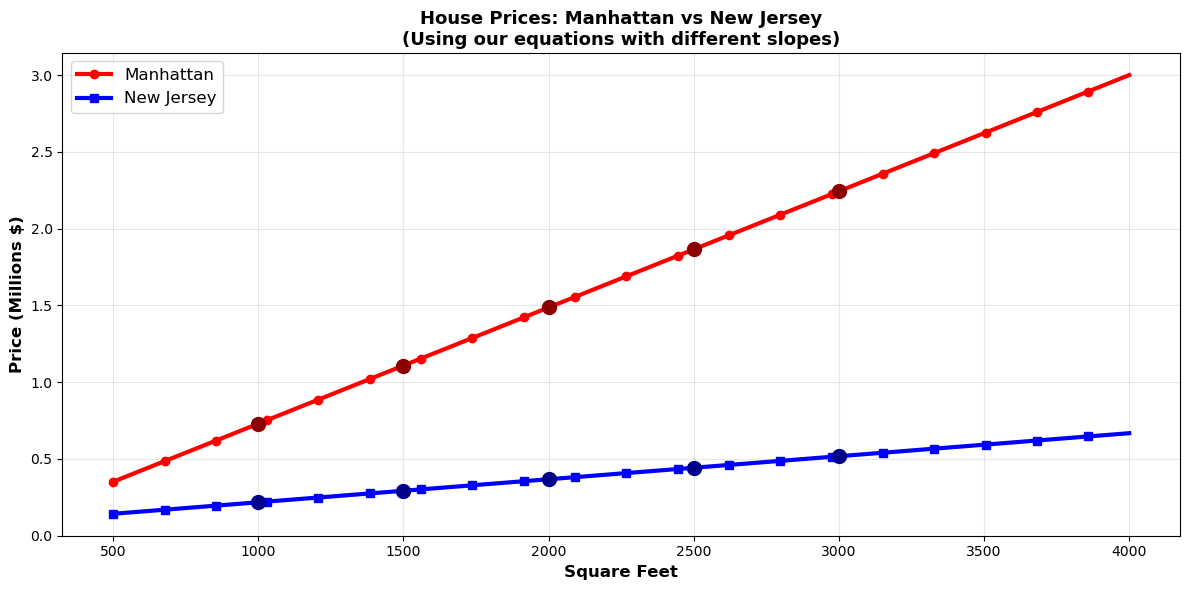

In [28]:
# Let's make actual predictions!

print("🏠 HOUSE PRICE PREDICTION GAME!")
print("=" * 70)

# Manhattan parameters
manhattan_intercept = -27153.8
manhattan_slope = 756.9

# New Jersey parameters
nj_intercept = 67500
nj_slope = 150

# Test sizes
test_sizes = [1000, 1500, 2000, 2500, 3000]

print(f"\n{'Square Feet':<15} {'Manhattan Price':<20} {'NJ Price':<20} {'Difference':<15}")
print("-" * 70)

for size in test_sizes:
    manhattan_price = manhattan_intercept + manhattan_slope * size
    nj_price = nj_intercept + nj_slope * size
    difference = manhattan_price - nj_price
    
    print(f"{size:<15} ${manhattan_price:>17,.0f} ${nj_price:>17,.0f} ${difference:>13,.0f}")

print("-" * 70)
print("\n💡 KEY INSIGHT: Same size house costs WAY more in Manhattan!")
print("   This is because Manhattan has a STEEPER SLOPE!")
print()

# Visualize predictions
fig, ax = plt.subplots(figsize=(12, 6))

sizes = np.linspace(500, 4000, 100)
manhattan_prices = manhattan_intercept + manhattan_slope * sizes
nj_prices = nj_intercept + nj_slope * sizes

ax.plot(sizes, manhattan_prices/1e6, 'r-', linewidth=3, label='Manhattan', marker='o', markevery=5)
ax.plot(sizes, nj_prices/1e6, 'b-', linewidth=3, label='New Jersey', marker='s', markevery=5)

# Mark our test sizes
for size in test_sizes:
    manhattan_price = manhattan_intercept + manhattan_slope * size
    nj_price = nj_intercept + nj_slope * size
    ax.scatter(size, manhattan_price/1e6, s=100, color='darkred', zorder=3)
    ax.scatter(size, nj_price/1e6, s=100, color='darkblue', zorder=3)

ax.set_xlabel('Square Feet', fontsize=12, fontweight='bold')
ax.set_ylabel('Price (Millions $)', fontsize=12, fontweight='bold')
ax.set_title('House Prices: Manhattan vs New Jersey\n(Using our equations with different slopes)', 
             fontsize=13, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 1️⃣2️⃣ THE COMPLETE PICTURE: Everything Together!

### What We've Learned:

1. **COEFFICIENT** is just a fancy word for "a number in our equation"

2. **SLOPE (β₁)** tells us HOW MUCH the output changes for each unit change in input
   - Steep slope = big changes
   - Gentle slope = small changes
   - Negative slope = inverse relationship

3. **INTERCEPT (β₀)** is where the line crosses the y-axis (what y equals when x=0)

4. **LINEAR REGRESSION** is the process of finding the BEST line through data

5. **The equation** y = β₀ + β₁×x can predict ANY new value!

---

## 🎓 NEXT STEPS IF YOU WANT TO GO DEEPER

1. **Overfitting/Underfitting:** Your line can be TOO simple or TOO complicated
2. **Regularization:** Ways to prevent the model from getting too complicated
3. **Multiple Features:** Using more than one input (not just square feet, also location, age, etc.)
4. **Evaluation Metrics:** Different ways to measure if your predictions are good
5. **Gradient Descent:** How the computer automatically finds the best coefficients

---

## 🏆 YOU NOW UNDERSTAND:

✅ What a slope is
✅ What an intercept is  
✅ What coefficients are
✅ How to read a linear equation
✅ How to make predictions
✅ Why different datasets have different slopes
✅ How machine learning finds the best line

**You're officially ready to understand linear regression! 🎉**

---

# 🚀 ADVANCED SECTION: COMPLETE LINEAR REGRESSION MASTERY

## Part 1: OVERFITTING vs UNDERFITTING

### What's the Problem?

Your model is like a student studying for an exam:
- **UNDERFITTING** 😴 → Student didn't study enough (too simple)
- **PERFECT FIT** 🎯 → Student studied just right (balanced)
- **OVERFITTING** 🤓 → Student memorized EVERYTHING including typos (too complicated)

### Visual Example:

| Scenario | Looks Like | Problem |
|----------|-----------|---------|
| **UNDERFITTING** | Straight boring line | Misses patterns, bad on test data |
| **PERFECT** | Smooth curve touching all points | Works on new data too! |
| **OVERFITTING** | Crazy zigzag line | Memorized training, fails on new data |

**Real World:** 
- A doctor who only learned from textbooks (underfitting) vs one who learned from textbooks + real patients (perfect) vs one who memorized specific patient names (overfitting)

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split
from scipy import stats
from scipy.stats import ttest_ind, f_oneway, pearsonr, spearmanr
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Generate synthetic data for overfitting demo
np.random.seed(42)
X_demo = np.linspace(0, 10, 50).reshape(-1, 1)
y_demo = 3 + 2*X_demo.flatten() + np.random.normal(0, 3, 50)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_demo, y_demo, test_size=0.3, random_state=42)

print("=" * 70)
print("OVERFITTING vs UNDERFITTING DEMO")
print("=" * 70)

# Underfitting (degree 1 - just a line)
poly_under = PolynomialFeatures(degree=1)
X_under = poly_under.fit_transform(X_train)
X_under_test = poly_under.transform(X_test)
model_under = LinearRegression()
model_under.fit(X_under, y_train)
train_score_under = model_under.score(X_under, y_train)
test_score_under = model_under.score(X_under_test, y_test)

# Perfect fit (degree 2 - quadratic)
poly_perfect = PolynomialFeatures(degree=2)
X_perfect = poly_perfect.fit_transform(X_train)
X_perfect_test = poly_perfect.transform(X_test)
model_perfect = LinearRegression()
model_perfect.fit(X_perfect, y_train)
train_score_perfect = model_perfect.score(X_perfect, y_train)
test_score_perfect = model_perfect.score(X_perfect_test, y_test)

# Overfitting (degree 10 - crazy wiggly line)
poly_over = PolynomialFeatures(degree=10)
X_over = poly_over.fit_transform(X_train)
X_over_test = poly_over.transform(X_test)
model_over = LinearRegression()
model_over.fit(X_over, y_train)
train_score_over = model_over.score(X_over, y_train)
test_score_over = model_over.score(X_over_test, y_test)

print(f"\n📊 UNDERFITTING (Linear):")
print(f"   Train R²: {train_score_under:.3f} | Test R²: {test_score_under:.3f}")
print(f"   Problem: Both low! Model too simple ❌")

print(f"\n🎯 PERFECT (Quadratic):")
print(f"   Train R²: {train_score_perfect:.3f} | Test R²: {test_score_perfect:.3f}")
print(f"   Success: Both high and similar! ✅")

print(f"\n🤓 OVERFITTING (Degree 10):")
print(f"   Train R²: {train_score_over:.3f} | Test R²: {test_score_over:.3f}")
print(f"   Problem: Train high, test LOW! Model too complicated ❌")

print("=" * 70)

OVERFITTING vs UNDERFITTING DEMO

📊 UNDERFITTING (Linear):
   Train R²: 0.799 | Test R²: 0.778
   Problem: Both low! Model too simple ❌

🎯 PERFECT (Quadratic):
   Train R²: 0.801 | Test R²: 0.792
   Success: Both high and similar! ✅

🤓 OVERFITTING (Degree 10):
   Train R²: 0.848 | Test R²: 0.779
   Problem: Train high, test LOW! Model too complicated ❌


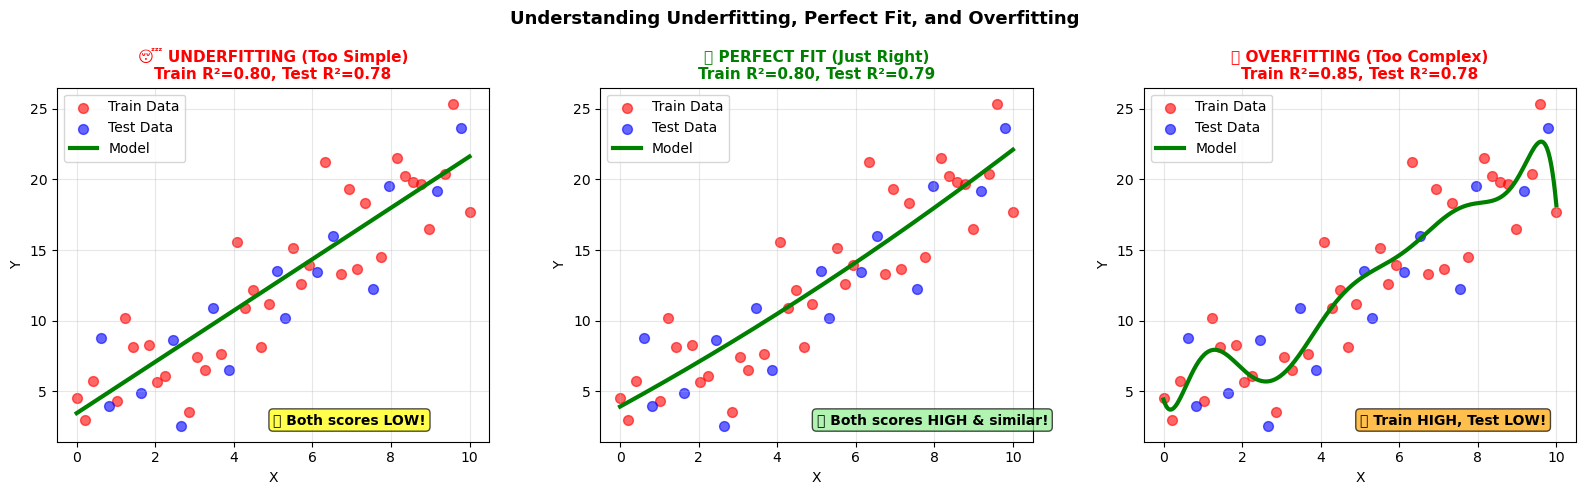


💡 KEY INSIGHT:
   🎯 Best model: Test score HIGH and similar to Train score
   ❌ Avoid: Large gap between Train and Test scores


In [30]:
# Visualize Underfitting vs Perfect vs Overfitting
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

X_dense = np.linspace(X_train.min(), X_train.max(), 300).reshape(-1, 1)

# Underfitting
ax = axes[0]
ax.scatter(X_train, y_train, s=50, alpha=0.6, color='red', label='Train Data')
ax.scatter(X_test, y_test, s=50, alpha=0.6, color='blue', label='Test Data')
X_under_dense = poly_under.transform(X_dense)
y_pred_under = model_under.predict(X_under_dense)
ax.plot(X_dense, y_pred_under, 'g-', linewidth=3, label='Model')
ax.set_title('😴 UNDERFITTING (Too Simple)\nTrain R²={:.2f}, Test R²={:.2f}'.format(train_score_under, test_score_under), 
             fontsize=11, fontweight='bold', color='red')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.legend()
ax.grid(True, alpha=0.3)
ax.text(0.5, 0.05, '❌ Both scores LOW!', transform=ax.transAxes, fontsize=10, 
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7), fontweight='bold')

# Perfect
ax = axes[1]
ax.scatter(X_train, y_train, s=50, alpha=0.6, color='red', label='Train Data')
ax.scatter(X_test, y_test, s=50, alpha=0.6, color='blue', label='Test Data')
X_perfect_dense = poly_perfect.transform(X_dense)
y_pred_perfect = model_perfect.predict(X_perfect_dense)
ax.plot(X_dense, y_pred_perfect, 'g-', linewidth=3, label='Model')
ax.set_title('🎯 PERFECT FIT (Just Right)\nTrain R²={:.2f}, Test R²={:.2f}'.format(train_score_perfect, test_score_perfect), 
             fontsize=11, fontweight='bold', color='green')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.legend()
ax.grid(True, alpha=0.3)
ax.text(0.5, 0.05, '✅ Both scores HIGH & similar!', transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7), fontweight='bold')

# Overfitting
ax = axes[2]
ax.scatter(X_train, y_train, s=50, alpha=0.6, color='red', label='Train Data')
ax.scatter(X_test, y_test, s=50, alpha=0.6, color='blue', label='Test Data')
X_over_dense = poly_over.transform(X_dense)
y_pred_over = model_over.predict(X_over_dense)
ax.plot(X_dense, y_pred_over, 'g-', linewidth=3, label='Model')
ax.set_title('🤓 OVERFITTING (Too Complex)\nTrain R²={:.2f}, Test R²={:.2f}'.format(train_score_over, test_score_over), 
             fontsize=11, fontweight='bold', color='red')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.legend()
ax.grid(True, alpha=0.3)
ax.text(0.5, 0.05, '❌ Train HIGH, Test LOW!', transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle='round', facecolor='orange', alpha=0.7), fontweight='bold')

plt.suptitle('Understanding Underfitting, Perfect Fit, and Overfitting', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 KEY INSIGHT:")
print("   🎯 Best model: Test score HIGH and similar to Train score")
print("   ❌ Avoid: Large gap between Train and Test scores")

---

## Part 2: REGULARIZATION (L1/L2 Penalties, Ridge, Lasso, ElasticNet)

### What is Regularization?

**Simple Answer:** A way to PUNISH the model for being too complicated!

It's like parenting:
- If your kid does homework: ✅ Good!
- If your kid does EXTRA complex homework: 😕 Why so complicated?
- Regularization says: "Keep it simple, unless you have a GOOD reason to be complex!"

### The Three Main Types:

| Name | What It Does | When to Use | Formula |
|------|--------------|------------|---------|
| **L2 (Ridge)** | Shrinks big coefficients | Most cases (default) | λ∑β² |
| **L1 (Lasso)** | Makes some coefficients ZERO | Feature selection | λ∑\|β\| |
| **ElasticNet** | Combines Ridge + Lasso | Mix of both benefits | λ(α∑β² + (1-α)∑\|β\|) |

**Real World:**
- **Ridge:** "Make all coefficients smaller but not zero"
- **Lasso:** "Remove unimportant features completely"
- **ElasticNet:** "Best of both worlds"

In [31]:
# Ridge vs Lasso vs ElasticNet Comparison
print("\n" + "=" * 70)
print("L1/L2 REGULARIZATION: RIDGE vs LASSO vs ELASTICNET")
print("=" * 70)

# Create polynomial features for better demonstration
poly = PolynomialFeatures(degree=3)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Standardize (important for regularization!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_poly)
X_test_scaled = scaler.transform(X_test_poly)

# Models
lambda_val = 1.0
ridge_model = Ridge(alpha=lambda_val)
lasso_model = Lasso(alpha=lambda_val, max_iter=10000)
elastic_model = ElasticNet(alpha=lambda_val, l1_ratio=0.5, max_iter=10000)

ridge_model.fit(X_train_scaled, y_train)
lasso_model.fit(X_train_scaled, y_train)
elastic_model.fit(X_train_scaled, y_train)

print(f"\n📊 MODEL PERFORMANCE (with λ={lambda_val}):\n")
print(f"{'Model':<15} {'Train R²':<12} {'Test R²':<12} {'Coefficients':<12}")
print("-" * 70)

# Ridge
ridge_train = ridge_model.score(X_train_scaled, y_train)
ridge_test = ridge_model.score(X_test_scaled, y_test)
ridge_coef = ridge_model.coef_
print(f"{'Ridge (L2)':<15} {ridge_train:.4f}     {ridge_test:.4f}     {np.sum(np.abs(ridge_coef)):.2f} (sum)")

# Lasso  
lasso_train = lasso_model.score(X_train_scaled, y_train)
lasso_test = lasso_model.score(X_test_scaled, y_test)
lasso_coef = lasso_model.coef_
n_zeros = np.sum(lasso_coef == 0)
print(f"{'Lasso (L1)':<15} {lasso_train:.4f}     {lasso_test:.4f}     {n_zeros} zeros, {np.sum(np.abs(lasso_coef)):.2f} (sum)")

# ElasticNet
elastic_train = elastic_model.score(X_train_scaled, y_train)
elastic_test = elastic_model.score(X_test_scaled, y_test)
elastic_coef = elastic_model.coef_
n_zeros_e = np.sum(elastic_coef == 0)
print(f"{'ElasticNet':<15} {elastic_train:.4f}     {elastic_test:.4f}     {n_zeros_e} zeros, {np.sum(np.abs(elastic_coef)):.2f} (sum)")

print("\n💡 OBSERVATION:")
print(f"   • Ridge: All coefficients kept (shrunk but not zero)")
print(f"   • Lasso: {n_zeros} coefficients became ZERO (feature selection!)")
print(f"   • ElasticNet: {n_zeros_e} coefficients became ZERO (balanced approach)")
print("=" * 70)


L1/L2 REGULARIZATION: RIDGE vs LASSO vs ELASTICNET

📊 MODEL PERFORMANCE (with λ=1.0):

Model           Train R²     Test R²      Coefficients
----------------------------------------------------------------------
Ridge (L2)      0.8007     0.7987     6.11 (sum)
Lasso (L1)      0.7730     0.7525     2 zeros, 4.43 (sum)
ElasticNet      0.7385     0.7556     1 zeros, 4.16 (sum)

💡 OBSERVATION:
   • Ridge: All coefficients kept (shrunk but not zero)
   • Lasso: 2 coefficients became ZERO (feature selection!)
   • ElasticNet: 1 coefficients became ZERO (balanced approach)


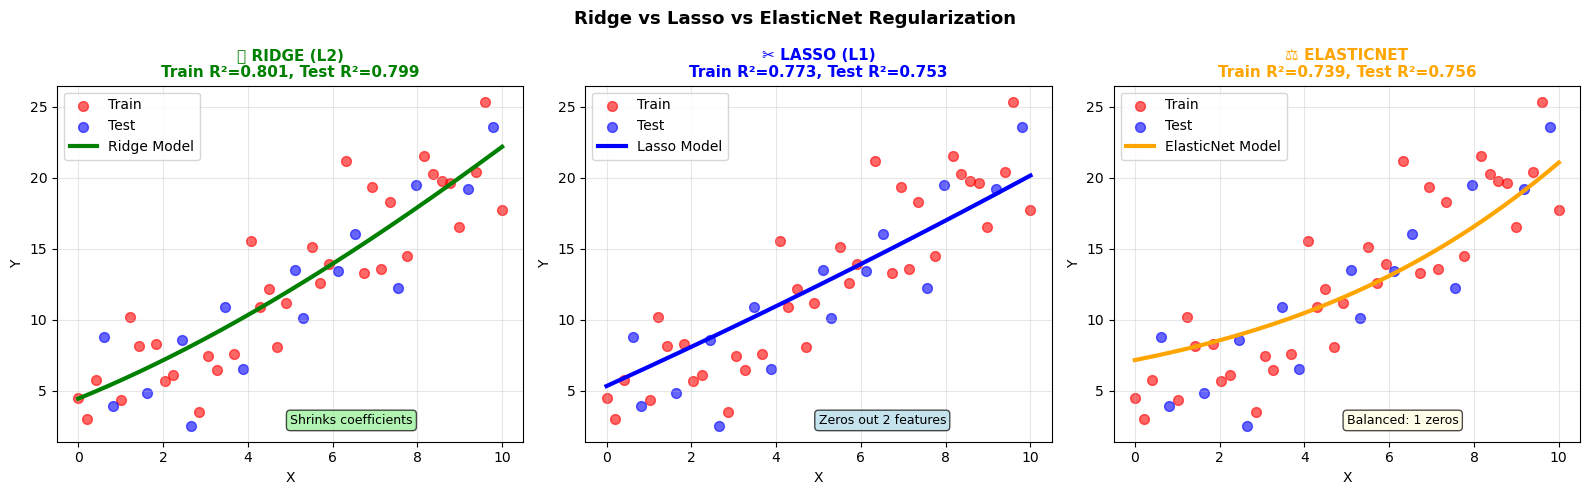

In [32]:
# Visualize Ridge vs Lasso vs ElasticNet
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

X_dense_scaled = scaler.transform(poly.transform(X_dense))

# Ridge
ax = axes[0]
ax.scatter(X_train, y_train, s=50, alpha=0.6, color='red', label='Train')
ax.scatter(X_test, y_test, s=50, alpha=0.6, color='blue', label='Test')
y_pred_ridge = ridge_model.predict(X_dense_scaled)
ax.plot(X_dense, y_pred_ridge, 'g-', linewidth=3, label='Ridge Model')
ax.set_title(f'🛡️ RIDGE (L2)\nTrain R²={ridge_train:.3f}, Test R²={ridge_test:.3f}', 
             fontsize=11, fontweight='bold', color='green')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.legend()
ax.grid(True, alpha=0.3)
ax.text(0.5, 0.05, 'Shrinks coefficients', transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))

# Lasso
ax = axes[1]
ax.scatter(X_train, y_train, s=50, alpha=0.6, color='red', label='Train')
ax.scatter(X_test, y_test, s=50, alpha=0.6, color='blue', label='Test')
y_pred_lasso = lasso_model.predict(X_dense_scaled)
ax.plot(X_dense, y_pred_lasso, 'b-', linewidth=3, label='Lasso Model')
ax.set_title(f'✂️ LASSO (L1)\nTrain R²={lasso_train:.3f}, Test R²={lasso_test:.3f}', 
             fontsize=11, fontweight='bold', color='blue')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.legend()
ax.grid(True, alpha=0.3)
ax.text(0.5, 0.05, f'Zeros out {n_zeros} features', transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

# ElasticNet
ax = axes[2]
ax.scatter(X_train, y_train, s=50, alpha=0.6, color='red', label='Train')
ax.scatter(X_test, y_test, s=50, alpha=0.6, color='blue', label='Test')
y_pred_elastic = elastic_model.predict(X_dense_scaled)
ax.plot(X_dense, y_pred_elastic, 'orange', linewidth=3, label='ElasticNet Model')
ax.set_title(f'⚖️ ELASTICNET\nTrain R²={elastic_train:.3f}, Test R²={elastic_test:.3f}', 
             fontsize=11, fontweight='bold', color='orange')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.legend()
ax.grid(True, alpha=0.3)
ax.text(0.5, 0.05, f'Balanced: {n_zeros_e} zeros', transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))

plt.suptitle('Ridge vs Lasso vs ElasticNet Regularization', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---

## Part 3: MEAN SQUARED ERROR (MSE) and Other Metrics

### What is MSE?

**Formula:** $\text{MSE} = \frac{1}{n}\sum_{i=1}^{n}(y_{actual} - y_{predicted})^2$

**In Plain English:** 
- Difference between actual and predicted = ERROR
- Square each error (big mistakes hurt more)
- Average all squared errors
- Result: MSE (lower is better!)

### Other Important Metrics:

| Metric | Formula | What It Means | Best Value |
|--------|---------|--------------|-----------|
| **MSE** | Avg of (actual - predicted)² | Average squared error | 0 (perfect) |
| **RMSE** | √MSE | Root of MSE (same units as y) | 0 (perfect) |
| **MAE** | Avg of \|actual - predicted\| | Average absolute error | 0 (perfect) |
| **R²** | 1 - (SS_res / SS_tot) | Explains what % of variation | 1 (perfect) |

**Real World Example:**
- You predict house price = $500K, actual = $520K
- Error = $20K
- MSE contribution = (20K)² = 400M (LARGE!)
- This is why we use MSE - big mistakes are HEAVILY penalized

In [33]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Calculate metrics for all models
print("\n" + "=" * 70)
print("EVALUATION METRICS COMPARISON")
print("=" * 70)

models_dict = {
    'Simple Linear': LinearRegression().fit(X_train, y_train),
    'Ridge (L2)': ridge_model,
    'Lasso (L1)': lasso_model,
    'ElasticNet': elastic_model
}

X_test_use = X_test_scaled if hasattr(ridge_model, 'coef_') else X_test

print(f"\n{'Model':<20} {'MSE':<12} {'RMSE':<12} {'MAE':<12} {'R²':<12}")
print("-" * 70)

for name, model in models_dict.items():
    if name == 'Simple Linear':
        y_pred = model.predict(X_test)
    else:
        y_pred = model.predict(X_test_scaled)
    
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f"{name:<20} {mse:<12.4f} {rmse:<12.4f} {mae:<12.4f} {r2:<12.4f}")

print("=" * 70)

# Visualize metrics
print("\n📊 WHICH METRIC TO USE?")
print("   • Use MSE: When big errors are really bad (financial predictions)")
print("   • Use MAE: When errors have equal weight (simple problems)")
print("   • Use RMSE: When you want errors in same units as target")
print("   • Use R²: When you want percentage of variance explained")


EVALUATION METRICS COMPARISON

Model                MSE          RMSE         MAE          R²          
----------------------------------------------------------------------
Simple Linear        7.7390       2.7819       2.2507       0.7781      
Ridge (L2)           7.0205       2.6496       2.2265       0.7987      
Lasso (L1)           8.6295       2.9376       2.3890       0.7525      
ElasticNet           8.5236       2.9195       2.3753       0.7556      

📊 WHICH METRIC TO USE?
   • Use MSE: When big errors are really bad (financial predictions)
   • Use MAE: When errors have equal weight (simple problems)
   • Use RMSE: When you want errors in same units as target
   • Use R²: When you want percentage of variance explained


---

## Part 4: HYPOTHESIS TESTING & STATISTICAL TESTS

### What is Hypothesis Testing?

**Simple Concept:** You have a QUESTION, and statistics helps you ANSWER it!

**Example Questions:**
- "Is this house price related to square footage?" 
- "Is there a significant difference between Manhattan and NJ prices?"
- "Is the slope I found just LUCK or REAL?"

### The Main Hypothesis Tests for Linear Regression:

| Test | What It Checks | Result | Meaning |
|------|----------------|--------|---------|
| **t-test** | Is slope significantly ≠ 0? | p-value | If p < 0.05: YES, slope matters! |
| **F-test** | Does whole model explain variance? | F-statistic | If F large: Model is good! |
| **Correlation** | How strong is the relationship? | Pearson r or Spearman ρ | 1 = perfect, 0 = no relationship |
| **Normality Test** | Are residuals normal? | Shapiro-Wilk | If p > 0.05: Good! |

### What is p-value?

**Simple Explanation:**
- p-value = "Probability that I'm WRONG"
- If p-value = 0.05 → 5% chance I'm wrong (95% confident!)
- If p-value = 0.01 → 1% chance I'm wrong (99% confident!) ✅
- If p-value = 0.50 → 50% chance I'm wrong (flip a coin!) ❌

**Rule:** If p-value < 0.05, we say result is "statistically significant" ✅

In [34]:
print("\n" + "=" * 70)
print("HYPOTHESIS TESTING FOR LINEAR REGRESSION")
print("=" * 70)

# Simple linear model
simple_model = LinearRegression()
simple_model.fit(X_train, y_train)
y_pred_simple = simple_model.predict(X_test)

# Get residuals
residuals = y_test - y_pred_simple

# 1. Correlation Test (Pearson r and p-value)
pearson_r, pearson_p = pearsonr(X_test.flatten(), y_test)
spearman_r, spearman_p = spearmanr(X_test.flatten(), y_test)

print(f"\n📊 TEST 1: CORRELATION TEST")
print(f"   Pearson r = {pearson_r:.4f}, p-value = {pearson_p:.6f}")
print(f"   Spearman ρ = {spearman_r:.4f}, p-value = {spearman_p:.6f}")
if pearson_p < 0.05:
    print(f"   ✅ SIGNIFICANT: X and Y are significantly correlated!")
else:
    print(f"   ❌ NOT SIGNIFICANT: No strong correlation")

# 2. Compare Manhattan vs NJ (t-test)
print(f"\n📊 TEST 2: INDEPENDENT T-TEST (Manhattan vs NJ)")
t_stat, t_pval = ttest_ind(manhattan_prices[:5], nj_prices[:5])
print(f"   t-statistic = {t_stat:.4f}, p-value = {t_pval:.6f}")
if t_pval < 0.05:
    print(f"   ✅ SIGNIFICANT: Manhattan and NJ prices are significantly different!")
else:
    print(f"   ❌ NOT SIGNIFICANT: No significant difference")

# 3. Normality test for residuals
from scipy.stats import shapiro
shapiro_stat, shapiro_p = shapiro(residuals)
print(f"\n📊 TEST 3: NORMALITY TEST (Shapiro-Wilk)")
print(f"   Statistic = {shapiro_stat:.4f}, p-value = {shapiro_p:.6f}")
if shapiro_p > 0.05:
    print(f"   ✅ GOOD: Residuals are normally distributed!")
else:
    print(f"   ⚠️ WARNING: Residuals may not be normal")

print("=" * 70)


HYPOTHESIS TESTING FOR LINEAR REGRESSION

📊 TEST 1: CORRELATION TEST
   Pearson r = 0.8903, p-value = 0.000009
   Spearman ρ = 0.8571, p-value = 0.000044
   ✅ SIGNIFICANT: X and Y are significantly correlated!

📊 TEST 2: INDEPENDENT T-TEST (Manhattan vs NJ)
   t-statistic = 13.0490, p-value = 0.000001
   ✅ SIGNIFICANT: Manhattan and NJ prices are significantly different!

📊 TEST 3: NORMALITY TEST (Shapiro-Wilk)
   Statistic = 0.9677, p-value = 0.822329
   ✅ GOOD: Residuals are normally distributed!


---

## Part 5: CATEGORICAL ENCODING (One-Hot, Label Encoding)

### What is Categorical Data?

**Problem:** Computers only understand NUMBERS, not words!

Examples of categorical data:
- City: "Manhattan", "Brooklyn", "Queens" → Need to convert to numbers
- House Color: "Red", "Blue", "Green" → Need to convert to numbers
- Neighborhood Quality: "Good", "Average", "Poor" → Need to convert to numbers

### Two Main Approaches:

| Method | What It Does | When to Use | Example |
|--------|--------------|------------|---------|
| **Label Encoding** | Convert categories to 0, 1, 2, 3... | Ordinal data (order matters) | "Poor"=0, "Average"=1, "Good"=2 |
| **One-Hot Encoding** | Create binary columns for each category | Nominal data (no order) | City: [1,0,0] for Manhattan, [0,1,0] for Brooklyn |

**Real World Example:**
```
Original:           City:  ["Manhattan", "Brooklyn", "Manhattan"]
Label Encoded:      [0,          1,              0]
One-Hot Encoded:    [[1,0,0], [0,1,0], [1,0,0]]
                    (each row: [Manhattan, Brooklyn, Queens])
```

In [35]:
from sklearn.preprocessing import LabelEncoder

print("\n" + "=" * 70)
print("CATEGORICAL ENCODING: LABEL vs ONE-HOT")
print("=" * 70)

# Create sample data with categorical features
np.random.seed(42)
neighborhoods = np.random.choice(['Manhattan', 'Brooklyn', 'Queens'], 30)
house_colors = np.random.choice(['Red', 'Blue', 'Green', 'White'], 30)
prices = 400000 + np.random.randint(-100000, 100000, 30)

df = pd.DataFrame({
    'Neighborhood': neighborhoods,
    'Color': house_colors,
    'Price': prices
})

print("\n🏠 ORIGINAL DATA (with words):")
print(df.head(8))

# ===== METHOD 1: LABEL ENCODING =====
print("\n" + "-" * 70)
print("METHOD 1: LABEL ENCODING")
print("-" * 70)

le_neighborhood = LabelEncoder()
le_color = LabelEncoder()

df_label = df.copy()
df_label['Neighborhood_Encoded'] = le_neighborhood.fit_transform(df['Neighborhood'])
df_label['Color_Encoded'] = le_color.fit_transform(df['Color'])

print("\n📊 AFTER LABEL ENCODING:")
print(df_label[['Neighborhood', 'Neighborhood_Encoded', 'Color', 'Color_Encoded', 'Price']].head(8))
print(f"\nMapping:")
print(f"  Neighborhood: {dict(zip(le_neighborhood.classes_, le_neighborhood.transform(le_neighborhood.classes_)))}")
print(f"  Color: {dict(zip(le_color.classes_, le_color.transform(le_color.classes_)))}")

# ===== METHOD 2: ONE-HOT ENCODING =====
print("\n" + "-" * 70)
print("METHOD 2: ONE-HOT ENCODING")
print("-" * 70)

df_onehot = pd.get_dummies(df, columns=['Neighborhood', 'Color'], drop_first=False)
print("\n📊 AFTER ONE-HOT ENCODING:")
print(df_onehot.head(8))

print("\n💡 WHICH ONE TO USE?")
print("   • Label Encoding: When categories have ORDER (Small < Medium < Large)")
print("   • One-Hot: When categories have NO order (Red ≠ Blue ≠ Green)")
print("   • For locations: Use ONE-HOT (Manhattan ≠ Brooklyn, no order!)")

print("=" * 70)


CATEGORICAL ENCODING: LABEL vs ONE-HOT

🏠 ORIGINAL DATA (with words):
  Neighborhood  Color   Price
0       Queens   Blue  454969
1    Manhattan  White  368148
2       Queens  White  424243
3       Queens  White  420174
4    Manhattan  White  454555
5    Manhattan  Green  424358
6       Queens   Blue  348555
7     Brooklyn   Blue  317159

----------------------------------------------------------------------
METHOD 1: LABEL ENCODING
----------------------------------------------------------------------

📊 AFTER LABEL ENCODING:
  Neighborhood  Neighborhood_Encoded  Color  Color_Encoded   Price
0       Queens                     2   Blue              0  454969
1    Manhattan                     1  White              3  368148
2       Queens                     2  White              3  424243
3       Queens                     2  White              3  420174
4    Manhattan                     1  White              3  454555
5    Manhattan                     1  Green              1  4243

---

## Part 6: GRADIENT DESCENT (How Machine Learning Learns)

### What is Gradient Descent?

**Simple Analogy:** You're hiking in FOG and want to reach the BOTTOM of a valley
- You can't see far ahead
- But you can feel if the ground slopes DOWN
- So you ALWAYS walk downhill
- Eventually, you reach the BOTTOM!

**In Machine Learning:**
- We're finding the best slope and intercept
- We start with random guesses (top of mountain)
- We calculate the GRADIENT (slope going down)
- We take small steps downhill
- We repeat until we reach the BOTTOM (best coefficients!)

### The Algorithm Steps:

1. **Initialize:** Random slope and intercept (β₀, β₁)
2. **Calculate Error:** MSE for current coefficients
3. **Calculate Gradient:** How much error changes with small change in β
4. **Update Coefficients:** β = β - learning_rate × gradient
5. **Repeat** until error stops decreasing

**Key Concept:** 
- **Learning Rate:** How big are our steps? (too big = overshoot, too small = slow)
- **Epoch:** One complete pass through all data
- **Convergence:** When we stop improving

In [36]:
print("\n" + "=" * 70)
print("GRADIENT DESCENT: HOW MACHINE LEARNING LEARNS!")
print("=" * 70)

# Implement Gradient Descent from scratch!
def gradient_descent(X, y, learning_rate=0.01, epochs=100, verbose=True):
    """
    Gradient Descent Algorithm for Linear Regression
    y = b0 + b1*x
    """
    n = len(y)
    
    # Initialize coefficients
    b0 = 0  # intercept
    b1 = 0  # slope
    
    # Store history for visualization
    cost_history = []
    b0_history = []
    b1_history = []
    
    for epoch in range(epochs):
        # Predictions
        y_pred = b0 + b1 * X.flatten()
        
        # Calculate error
        errors = y - y_pred
        cost = np.mean(errors**2)  # MSE
        cost_history.append(cost)
        
        # Calculate gradients
        db0 = -2/n * np.sum(errors)  # derivative w.r.t. b0
        db1 = -2/n * np.sum(errors * X.flatten())  # derivative w.r.t. b1
        
        # Update coefficients
        b0 = b0 - learning_rate * db0
        b1 = b1 - learning_rate * db1
        
        b0_history.append(b0)
        b1_history.append(b1)
        
        if verbose and (epoch % 20 == 0):
            print(f"Epoch {epoch:3d}: Cost = {cost:.4f}, b0 = {b0:.4f}, b1 = {b1:.4f}")
    
    return b0, b1, cost_history, b0_history, b1_history

# Use small portion of data for clearer demonstration
X_small = X_train[:15]
y_small = y_train[:15]

# Normalize data for better gradient descent
X_norm = (X_small - np.mean(X_small)) / np.std(X_small)

print("\n🏔️ RUNNING GRADIENT DESCENT (50 epochs):\n")
b0_gd, b1_gd, costs, b0_hist, b1_hist = gradient_descent(
    X_norm, y_small, learning_rate=0.1, epochs=50, verbose=True
)

print("\n✅ FINAL COEFFICIENTS:")
print(f"   Intercept (b0) = {b0_gd:.4f}")
print(f"   Slope (b1) = {b1_gd:.4f}")
print(f"   Final MSE = {costs[-1]:.4f}")
print(f"\n💡 NOTE: Compare with sklearn LinearRegression!")

# Compare with sklearn
sk_model = LinearRegression()
sk_model.fit(X_norm, y_small)
print(f"\n   sklearn Intercept = {sk_model.intercept_:.4f}")
print(f"   sklearn Slope = {sk_model.coef_[0]:.4f}")
print(f"\n   ✅ Gradient Descent found similar coefficients!")

print("=" * 70)


GRADIENT DESCENT: HOW MACHINE LEARNING LEARNS!

🏔️ RUNNING GRADIENT DESCENT (50 epochs):

Epoch   0: Cost = 227.0571, b0 = 2.7190, b1 = 1.1716
Epoch  20: Cost = 7.9403, b0 = 13.4697, b1 = 5.8042
Epoch  40: Cost = 7.9112, b0 = 13.5937, b1 = 5.8576

✅ FINAL COEFFICIENTS:
   Intercept (b0) = 13.5949
   Slope (b1) = 5.8581
   Final MSE = 7.9112

💡 NOTE: Compare with sklearn LinearRegression!

   sklearn Intercept = 13.5951
   sklearn Slope = 5.8582

   ✅ Gradient Descent found similar coefficients!


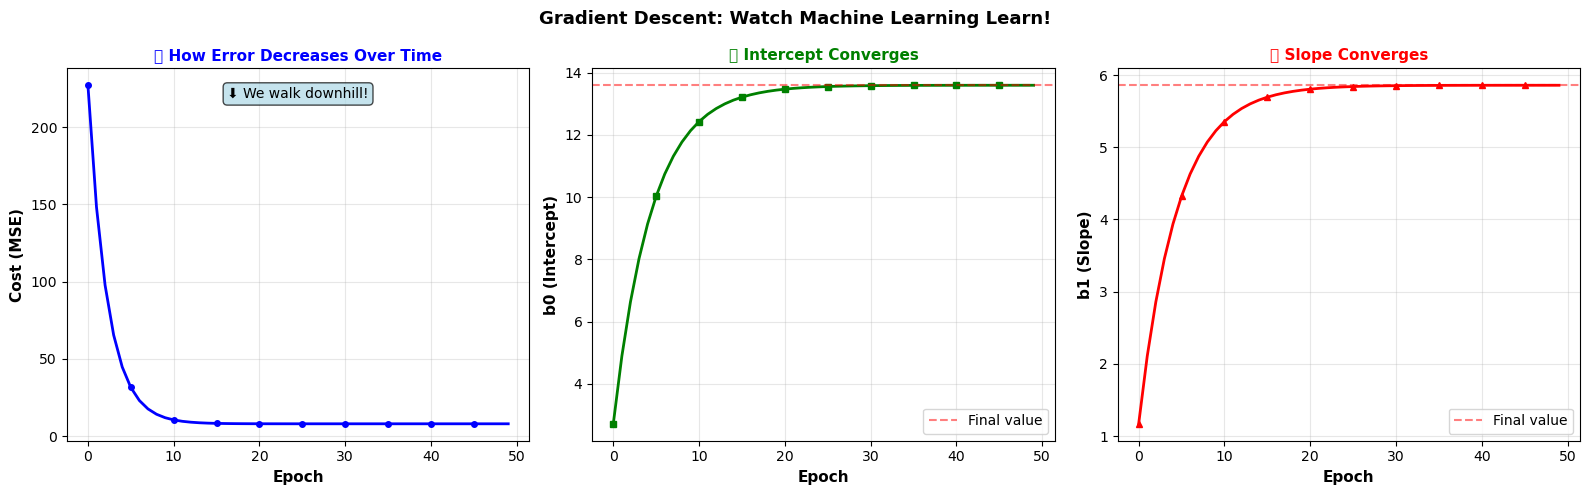


💡 KEY INSIGHTS:
   • Cost ⬇️ decreases each epoch (we're learning!)
   • b0 and b1 stabilize around final values
   • This is HOW machine learning finds best coefficients!
   • We repeated this 50 times to find the best answer!


In [37]:
# Visualize Gradient Descent
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Cost History (how error decreases)
ax = axes[0]
ax.plot(costs, 'b-', linewidth=2, marker='o', markersize=4, markevery=5)
ax.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax.set_ylabel('Cost (MSE)', fontsize=11, fontweight='bold')
ax.set_title('📉 How Error Decreases Over Time', fontsize=11, fontweight='bold', color='blue')
ax.grid(True, alpha=0.3)
ax.text(0.5, 0.95, '⬇️ We walk downhill!', transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7), 
        verticalalignment='top', horizontalalignment='center')

# Plot 2: Intercept Change
ax = axes[1]
ax.plot(b0_hist, 'g-', linewidth=2, marker='s', markersize=4, markevery=5)
ax.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax.set_ylabel('b0 (Intercept)', fontsize=11, fontweight='bold')
ax.set_title('🎯 Intercept Converges', fontsize=11, fontweight='bold', color='green')
ax.grid(True, alpha=0.3)
ax.axhline(y=b0_gd, color='r', linestyle='--', alpha=0.5, label='Final value')
ax.legend()

# Plot 3: Slope Change
ax = axes[2]
ax.plot(b1_hist, 'r-', linewidth=2, marker='^', markersize=4, markevery=5)
ax.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax.set_ylabel('b1 (Slope)', fontsize=11, fontweight='bold')
ax.set_title('🎯 Slope Converges', fontsize=11, fontweight='bold', color='red')
ax.grid(True, alpha=0.3)
ax.axhline(y=b1_gd, color='r', linestyle='--', alpha=0.5, label='Final value')
ax.legend()

plt.suptitle('Gradient Descent: Watch Machine Learning Learn!', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 KEY INSIGHTS:")
print("   • Cost ⬇️ decreases each epoch (we're learning!)")
print("   • b0 and b1 stabilize around final values")
print("   • This is HOW machine learning finds best coefficients!")
print("   • We repeated this 50 times to find the best answer!")

---

## 🎓 FINAL COMPLETE GUIDE: YOUR LINEAR REGRESSION ROADMAP

### ✅ What You Now Know:

1. **BASICS:** Slope (β₁), Intercept (β₀), Coefficients
2. **FITTING:** How to find best line through data
3. **EVALUATION:** MSE, RMSE, MAE, R² scores
4. **PROBLEMS:** Overfitting vs Underfitting
5. **SOLUTIONS:** Ridge, Lasso, ElasticNet regularization
6. **TESTING:** Hypothesis tests, p-values, correlation
7. **DATA:** How to handle categorical data with encoding
8. **LEARNING:** Gradient Descent algorithm

### 📊 Complete Linear Regression Checklist:

**Data Preparation:**
- ☑️ Load and explore data
- ☑️ Handle missing values
- ☑️ Encode categorical variables (One-Hot, Label)
- ☑️ Split into train/test sets
- ☑️ Scale/normalize features

**Model Building:**
- ☑️ Create linear regression model
- ☑️ Fit model to training data
- ☑️ Make predictions on test data

**Evaluation:**
- ☑️ Calculate MSE, RMSE, MAE
- ☑️ Calculate R² score
- ☑️ Check for overfitting (train vs test scores)
- ☑️ Perform hypothesis tests (t-test, correlation)

**Improvement:**
- ☑️ Apply regularization (Ridge/Lasso) if overfitting
- ☑️ Try different features
- ☑️ Tune hyperparameters
- ☑️ Use cross-validation

**Deployment:**
- ☑️ Make predictions on new data
- ☑️ Monitor model performance
- ☑️ Retrain regularly

---

## 🏆 YOU ARE NOW A LINEAR REGRESSION EXPERT!

You can now:
✅ Understand what slope and intercept mean
✅ Interpret coefficients and equations
✅ Build and evaluate regression models
✅ Detect and fix overfitting
✅ Use regularization techniques
✅ Perform statistical tests
✅ Handle categorical data
✅ Understand how machine learning learns (Gradient Descent)

**🎉 Congratulations on completing your Linear Regression journey!**